# Natural Language Processing (NLP) Giriş

Bu çalışmada, cappuccino ürünü hakkındaki müşterilerin değerlendirmelerini nasıl işleyebileceğimizi ve bu amaç doğrultusunda hangi teknikleri kullanacağımızı göreceğiz.

Bu dersin sonunda şunları yapabiliyor olmayı hedefliyoruz:

1. Sentiment analizini anlamak
2. Metin verisi üzerinde ihtiyacımız olan ön işleme adımlarını uygulamak
3. Gerçekleştirilen ön işleme adımları sonrasında modeli oluşturmak

## 1. Veri Setini Okuma

In [1]:
import nltk
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('coffee.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  542 non-null    object
 1   stars    542 non-null    int64 
 2   reviews  542 non-null    object
dtypes: int64(1), object(2)
memory usage: 12.8+ KB


In [3]:
data

,user_id,stars,reviews
0,A2XP9IN4JOMROD,1,I wanted to love this. I was even prepared for...
1,A2TS09JCXNV1VD,5,Grove Square Cappuccino Cups were excellent. T...
2,AJ3L5J7GN09SV,2,I bought the Grove Square hazelnut cappuccino ...
3,A3CZD34ZTUJME7,1,"I love my Keurig, and I love most of the Keuri..."
4,AWKN396SHAQGP,1,It's a powdered drink. No filter in k-cup.<br ...
...,...,...,...
537,A398T38COTS30K,5,This is my favorite K-Cup flavor. I like my c...
538,A1B410YK9O18XZ,5,If you are looking for the taste of French Van...
539,A1W85A81467TCW,5,I have purchased and used 3 boxes of the Hazel...
540,A103FOM06QPAX8,5,"Yummy, great tasting and very convenient. Onl..."


İlk örnekte elimizde oldukça basit bir veri seti var. Dataframeimiz yalnızca,

- Yorum yapan kullanıcı numaraları
- Kullanıcıların verdiği yıldız puanları
- Bu puanları verirken yazdıkları yorumlardan oluşuyor.

İlk aşamada verimizi biraz keşfetmeye çalışalım.

## 2. Exploratory Data Analysis

In [4]:
data.stars.value_counts(normalize=True)

5    0.568266
1    0.177122
4    0.119926
2    0.083026
3    0.051661
Name: stars, dtype: float64

Veri setimizde verilen yıldız puanlarının dağılımına baktığımızda kullanıcıların bu ürüne **yaklaşık %57'lik bir oranla 5 yıldız** verdiğini görüyoruz.

Ancak bu yanında **1 yıldız veren** kullanıcıların oranı da yaklaşık **%18**. Elimizde ne kadar az sayıda verimiz olsa da, bir sentiment analizi gerçekleştirmeye uygun olan bir veri dağılımımız var gibi gözüküyor.

Sentiment Analizi temel olarak çoğunlukla kullanıcıların yaptığı yorumlar incelenerek, bu yorumların içerisinden duygu çıkarımı yapılmasına dayanan ve bu sayede satıcılara çok önemli bilgiler sağlayabilen bir analiz çeşididir.

> **NOT:** Sentiment Analizi hakkında daha detaylı bilgiler için [bu linki](https://monkeylearn.com/sentiment-analysis/) ziyaret edebilirsiniz.

In [5]:
# 3 yıldız verilen yorumlar, ne pozitif ne negatif bir duygu durumunu belirttiği için onları çıkarıyoruz
data = data[data.stars!=3]

# 4/5 Yıldız --> POZİTİF, 1/2 Yıldız --> NEGATİF
data['sentiment'] = np.where(data['stars'] >= 4, 'positive', 'negative')

data = data[['sentiment', 'reviews']]
data.head()

/var/folders/5q/z3mk3kqj0d77y0jhx_gdsrtm0000gn/T/ipykernel_90207/3021075468.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['sentiment'] = np.where(data['stars'] >= 4, 'positive', 'negative')


,sentiment,reviews
0,negative,I wanted to love this. I was even prepared for...
1,positive,Grove Square Cappuccino Cups were excellent. T...
2,negative,I bought the Grove Square hazelnut cappuccino ...
3,negative,"I love my Keurig, and I love most of the Keuri..."
4,negative,It's a powdered drink. No filter in k-cup.<br ...


In [6]:
# 3 yıldızlı yorumları çıkardıktan sonra veri setimizdeki satır sayımızı tekrardan kontrol edelim
len(data)

514

In [7]:
# Veri setimizin büyük bir kısmı pozitif duygu durumunu gösteren yorumlardan oluşuyor
data.sentiment.value_counts(normalize=True)

positive    0.725681
negative    0.274319
Name: sentiment, dtype: float64

## 3. Ön İşleme Adımları

Hatırlarsanız, Natural Language Processing (NLP) slaytımızda metin verileri üzerinde hangi ön işleme adımlarına dikkat etmemiz gerektiğini konuşmuştuk.

O yüzden yorumlarımızı tokenize etmeden önce yorumlarımızın içeriğini biraz temizleyelim. İlk olarak **gereksiz karakterden kurtulma** ile başlayalım.

In [8]:
import re
import string

# Yorumlar içerisinde geçen sayısal değerleri kaldırma
alphanumeric = lambda x: re.sub('\w*\d\w*', ' ', x)
# Noktalama işaretlerini kaldırma ve tüm kelimeleri küçük harfe dönüştürme
punc_lower = lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x.lower()) 

data['reviews'] = data.reviews.map(alphanumeric).map(punc_lower)
data

,sentiment,reviews
0,negative,i wanted to love this i was even prepared for...
1,positive,grove square cappuccino cups were excellent t...
2,negative,i bought the grove square hazelnut cappuccino ...
3,negative,i love my keurig and i love most of the keuri...
4,negative,it s a powdered drink no filter in k cup br ...
...,...,...
537,positive,this is my favorite k cup flavor i like my c...
538,positive,if you are looking for the taste of french van...
539,positive,i have purchased and used boxes of the hazel...
540,positive,yummy great tasting and very convenient onl...


Sunumda da konuştuğumuz üzere günlük hayatta kullandığımız kelimelerin birçok çekimi vardır. Bu sebepten dolayı **severim** ve **seviyorum** gibi kelimeler bile birbirinden farklı kategorilermiş gibi algılanırlar. Şimdi biz de bu durumu düzeltmek için yorumlarımıza `stemmer` uygulayalım.

> **NOT:** `from nltk import LancasterStemmer` kullanarak da kelime köklerine ulaşmayı deneyebilirsiniz.

In [9]:
from nltk import SnowballStemmer

sbs = SnowballStemmer(language='english')

In [10]:
def stemmer(text):
    text = [sbs.stem(word) for word in text.split(' ')]
    text = " ".join(text)
    return text

data.reviews = data.reviews.apply(stemmer)

In [11]:
data.reviews

0      i want to love this  i was even prepar for it ...
1      grove squar cappuccino cup were excel  tast re...
2      i bought the grove squar hazelnut cappuccino k...
3      i love my keurig  and i love most of the keuri...
4      it s a powder drink  no filter in k cup  br   ...
                             ...                        
537    this is my favorit k cup flavor   i like my co...
538    if you are look for the tast of french vanilla...
539    i have purchas and use   box of the hazelnut c...
540    yummi  great tast and veri conveni   onli draw...
541    for an enjoy chang from a coffe routin  i thou...
Name: reviews, Length: 514, dtype: object

In [12]:
data

,sentiment,reviews
0,negative,i want to love this i was even prepar for it ...
1,positive,grove squar cappuccino cup were excel tast re...
2,negative,i bought the grove squar hazelnut cappuccino k...
3,negative,i love my keurig and i love most of the keuri...
4,negative,it s a powder drink no filter in k cup br ...
...,...,...
537,positive,this is my favorit k cup flavor i like my co...
538,positive,if you are look for the tast of french vanilla...
539,positive,i have purchas and use box of the hazelnut c...
540,positive,yummi great tast and veri conveni onli draw...


## 4. Tokenization & Model Oluşturma

In [13]:
X = data.reviews
y = data.sentiment

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Artık modelimizi oluşturacağımız için düzenlediğimiz metin verilerini tokenize etmemiz gerekiyor. Metin verilerini tokenize ederken de karşımıza 2 temel yaklaşım tarzı çıkıyor. Bunlar,

- **CountVectorizer**
- **TFIDFVectorizer (Term Frequency – Inverse Document Frequency)**

İlk olarak `CountVectorizer` yöntemini deneyelim.

## 4.1. CountVectorizer

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

cv1 = CountVectorizer(stop_words='english') # Stop wordsleri kaldırma

# Train ve Test veri setlerine CountVectorizer uygulama
X_train_cv1 = cv1.fit_transform(X_train)
X_test_cv1  = cv1.transform(X_test)

pd.DataFrame(X_train_cv1.toarray(), columns=cv1.get_feature_names_out()).head()

,abl,abomin,absolut,accept,accid,actual,ad,add,addict,addit,...,xx,ya,year,yes,yessire,yesterday,york,yuck,yum,yummi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
# 2'li N-Gram yöntemini kullanarak tokenize etme
cv2 = CountVectorizer(ngram_range=(2,2), binary=True, stop_words='english')

X_train_cv2 = cv2.fit_transform(X_train)
X_test_cv2  = cv2.transform(X_test)

pd.DataFrame(X_train_cv2.toarray(), columns=cv2.get_feature_names_out()).head()

,abl cappuccino,abl drink,abl finish,abl longer,abl make,abl return,abl switch,abomin bet,absolut awesom,absolut creamer,...,yummi don,yummi gas,yummi great,yummi perfect,yummi price,yummi run,yummi strong,yummi suitabl,yummi treat,yummi won
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


İlk olarak `LogisticRegression` algoritmasını kullanarak modelimizi oluşturalım.

In [17]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

In [18]:
# Kelimelere ayırarak oluşturulan DataFrame
lr.fit(X_train_cv1, y_train)
y_pred_cv1 = lr.predict(X_test_cv1)

In [19]:
# 2'li N-Gram yöntemi kullanılarak oluşturulan DataFrame
lr.fit(X_train_cv2, y_train)
y_pred_cv2 = lr.predict(X_test_cv2)

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def conf_matrix(actual, predicted):
    plt.figure(figsize=[8,8])
    cm = confusion_matrix(actual, predicted)
    sns.heatmap(cm, xticklabels=['Predicted Negative', 'Predicted Positive'], 
                yticklabels=['Actual Negative', 'Actual Positive'], annot=True,
                fmt='d', annot_kws={'fontsize':35}, cmap="YlGnBu", square=True);

    accuracy = accuracy_score(actual, predicted)
    precision = precision_score(actual, predicted, pos_label='negative', zero_division=1)
    recall = recall_score(actual, predicted, pos_label='negative', zero_division=1)
    f1 = f1_score(actual, predicted, pos_label='negative', zero_division=1)
    # pos_label parametresi precision, recall ve f1 score unu görmek istediğimiz labelı soruyor
    # zero_division parametresi 0'a bölme işlemini gerçekleşirse uyarı verip vermeyeceğini soruyor (1=uyarı verme)

    cm_results = [accuracy, precision, recall, f1]
    return cm_results

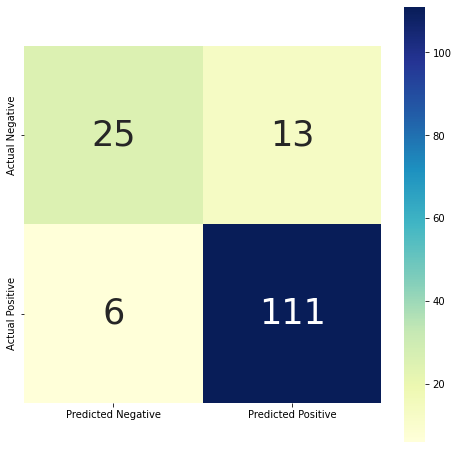

In [21]:
# İlk modelimizden elde ettiğimiz hata matrisi
cm1 = conf_matrix(y_test, y_pred_cv1)

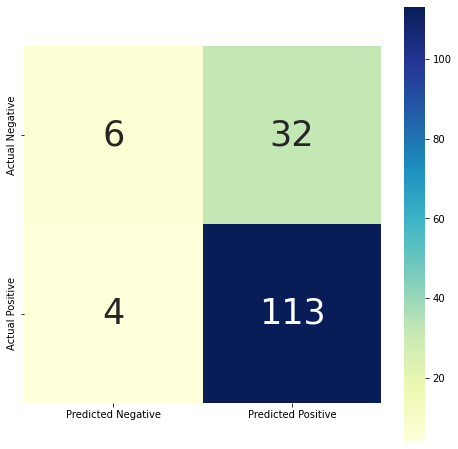

In [22]:
# İkinci modelimizden elde ettiğimiz hata matrisi
cm2 = conf_matrix(y_test, y_pred_cv2)

Son aşama olarak da ürettiğimiz bu 2 modelden elde ettiğimiz sonuçları bir tablo üzerinde görelim.

In [23]:
results = pd.DataFrame(list(zip(cm1, cm2)))
results = results.set_index([['Accuracy', 'Precision', 'Recall', 'F1 Score']])
results.columns = ['LR(Word)-CV', 'LR(N-Grams)-CV']
results

,LR(Word)-CV,LR(N-Grams)-CV
Accuracy,0.877419,0.767742
Precision,0.806452,0.600000
Recall,0.657895,0.157895
F1 Score,0.724638,0.250000


> **SORU:** Hangi modelden elde ettiğimiz sonuçlar daha iyi gibi duruyor?

`Naive Bayes` algoritması metin verileri üzerinden geliştirilen modellerde genellikle oldukça başarılı çalışan bir algoritmadır. O zaman bir de Naive Bayes'den elde ettiğimiz sonuçlara bakalım.

In [24]:
# İlk olarak MultinomialNB algoritmasıyla modellerimizi eğitelim
from sklearn.naive_bayes import MultinomialNB

mnb1 = MultinomialNB()
mnb1.fit(X_train_cv1, y_train)

mnb2 = MultinomialNB()
mnb2.fit(X_train_cv2, y_train)

y_pred_cv1_mnb = mnb1.predict(X_test_cv1)
y_pred_cv2_mnb = mnb2.predict(X_test_cv2)

In [25]:
# Ardından da BernoulliNB algoritmasıyla
from sklearn.naive_bayes import BernoulliNB

bnb1 = BernoulliNB()
bnb1.fit(X_train_cv1, y_train)

bnb2 = BernoulliNB()
bnb2.fit(X_train_cv2, y_train)

y_pred_cv1_bnb = bnb1.predict(X_test_cv1)
y_pred_cv2_bnb = bnb2.predict(X_test_cv2)

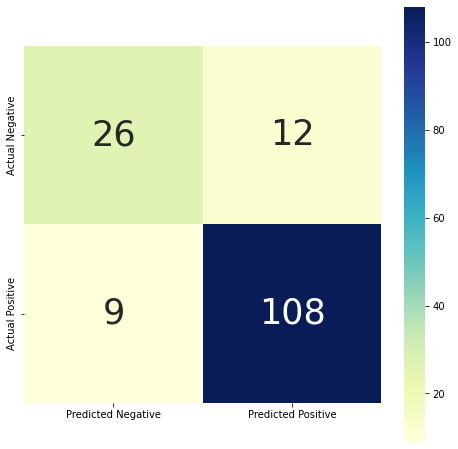

In [26]:
# MultinomialNB & Kelime
cm3 = conf_matrix(y_test, y_pred_cv1_mnb)

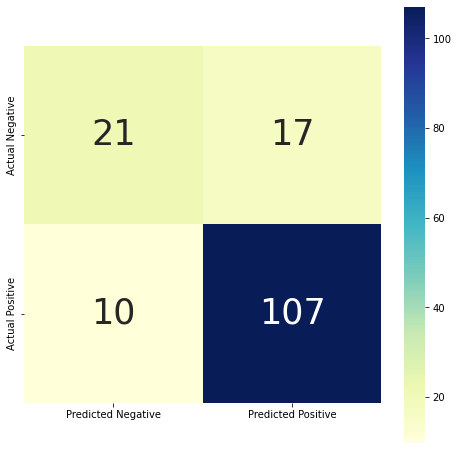

In [27]:
# MultinomialNB & 2'li N-Grams
cm4 = conf_matrix(y_test, y_pred_cv2_mnb)

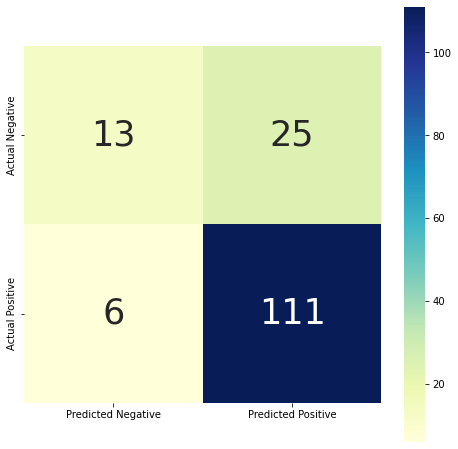

In [28]:
# BernoulliNB & Kelime
cm5 = conf_matrix(y_test, y_pred_cv1_bnb)

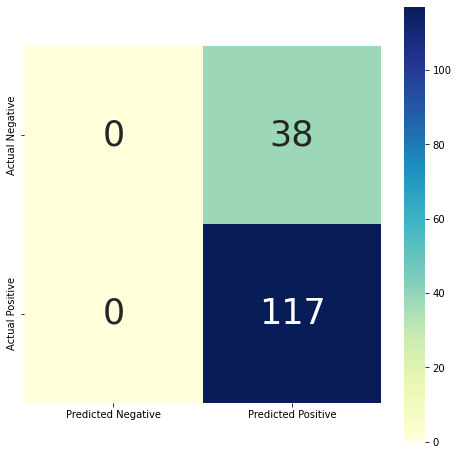

In [29]:
# BernoulliNB & 2'li N-Grams
cm6 = conf_matrix(y_test, y_pred_cv2_bnb)

In [30]:
results_nb = pd.DataFrame(list(zip(cm3, cm4, cm5, cm6)))
results_nb = results_nb.set_index([['Accuracy', 'Precision', 'Recall', 'F1 Score']])
results_nb.columns = ['MNB(Word)-CV', 'MNB(N-Grams)-CV', 'BNB(Word)-CV', 'BNB(N-Grams)-CV']
results_nb

results = pd.concat([results, results_nb], axis=1)
results

,LR(Word)-CV,LR(N-Grams)-CV,MNB(Word)-CV,MNB(N-Grams)-CV,BNB(Word)-CV,BNB(N-Grams)-CV
Accuracy,0.877419,0.767742,0.864516,0.825806,0.800000,0.754839
Precision,0.806452,0.600000,0.742857,0.677419,0.684211,1.000000
Recall,0.657895,0.157895,0.684211,0.552632,0.342105,0.000000
F1 Score,0.724638,0.250000,0.712329,0.608696,0.456140,0.000000


> **SORU:** Birinci modelde bir değişiklik oldu mu?

Şimdi de `TfidfVectorizer` yöntemini deneyelim.

## 4.2. TFIDF-Vectorizer

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf1 = TfidfVectorizer(stop_words='english')
X_train_tfidf1 = tfidf1.fit_transform(X_train)
X_test_tfidf1  = tfidf1.transform(X_test)

tfidf2 = TfidfVectorizer(ngram_range=(2,2), binary=True, stop_words='english')
X_train_tfidf2 = tfidf2.fit_transform(X_train)
X_test_tfidf2  = tfidf2.transform(X_test)

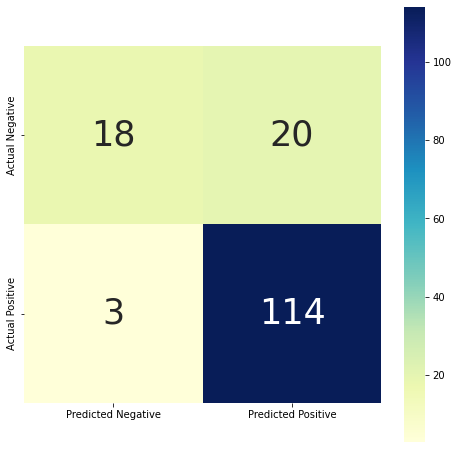

In [32]:
lr.fit(X_train_tfidf1, y_train)
y_pred_tfidf1_lr = lr.predict(X_test_tfidf1)

# Logistic Regresyon & Kelime
cm7 = conf_matrix(y_test, y_pred_tfidf1_lr)

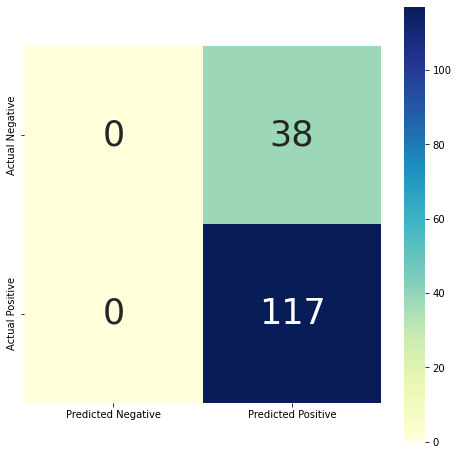

In [33]:
lr.fit(X_train_tfidf2, y_train)
y_pred_tfidf2_lr = lr.predict(X_test_tfidf2)

# Logistic Regresyon & 2'li N-Grams
cm8 = conf_matrix(y_test, y_pred_tfidf2_lr)

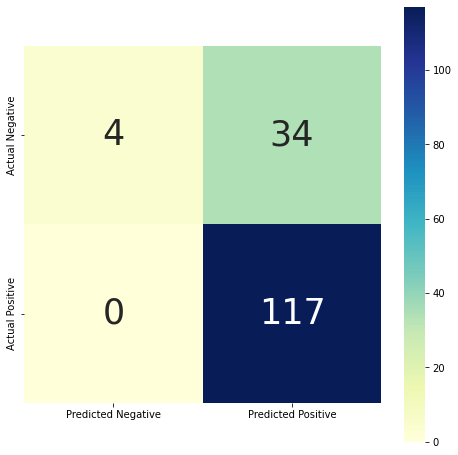

In [34]:
mnb1.fit(X_train_tfidf1.toarray(), y_train)
y_pred_tfidf1_mnb = mnb1.predict(X_test_tfidf1)

# MultinominalNB & Kelime
cm9 = conf_matrix(y_test, y_pred_tfidf1_mnb)

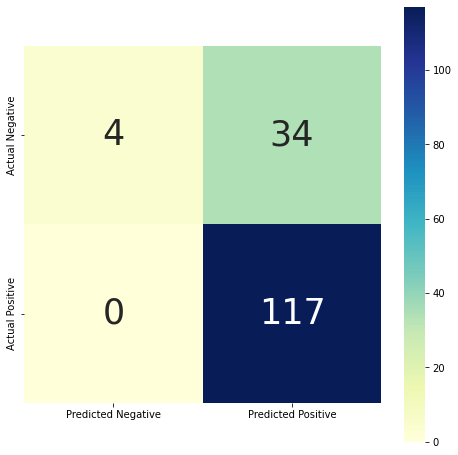

In [35]:
mnb2.fit(X_train_tfidf1.toarray(), y_train)
y_pred_tfidf2_mnb = mnb2.predict(X_test_tfidf1)

# MultinominalNB & 2'li N-Grams
cm10 = conf_matrix(y_test, y_pred_tfidf2_mnb)

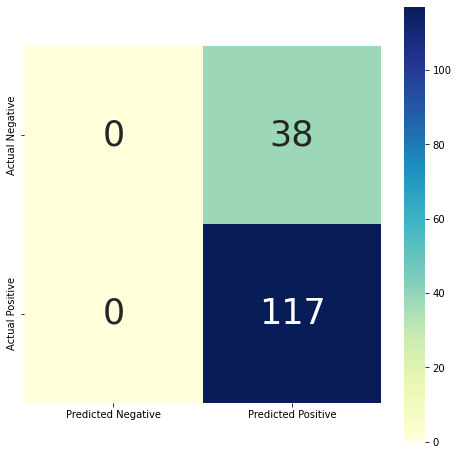

In [36]:
bnb1.fit(X_train_tfidf2.toarray(), y_train)
y_pred_tfidf1_bnb = bnb1.predict(X_test_tfidf2)

# BernoulliNB & Kelime
cm11 = conf_matrix(y_test, y_pred_tfidf1_bnb)

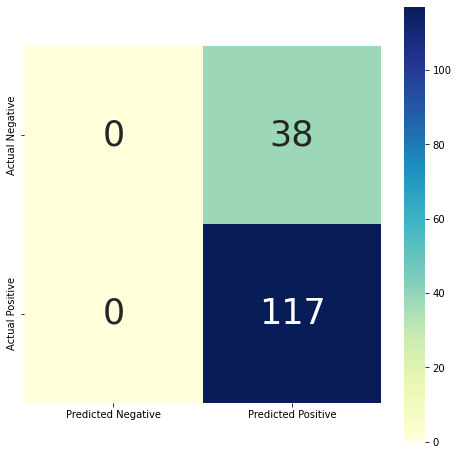

In [37]:
bnb2.fit(X_train_tfidf2.toarray(), y_train)
y_pred_tfidf2_bnb = bnb2.predict(X_test_tfidf2)

# BernoulliNB & 2'li N-Grams
cm12 = conf_matrix(y_test, y_pred_tfidf2_bnb)

In [38]:
results_tf = pd.DataFrame(list(zip(cm7, cm8, cm9, cm10, cm11, cm12)))
results_tf = results_tf.set_index([['Accuracy', 'Precision', 'Recall', 'F1 Score']])
results_tf.columns = ['LR(Word)-TFIDF', 'LR(N-Grams)-TFIDF', 'MNB(Word)-TFIDF', 
                      'MNB(N-Grams)-TFIDF', 'BNB(Word)-TFIDF', 'BNB(N-Grams)-TFIDF']
results_tf

results = pd.concat([results, results_tf], axis=1)
results

,LR(Word)-CV,LR(N-Grams)-CV,MNB(Word)-CV,MNB(N-Grams)-CV,BNB(Word)-CV,BNB(N-Grams)-CV,LR(Word)-TFIDF,LR(N-Grams)-TFIDF,MNB(Word)-TFIDF,MNB(N-Grams)-TFIDF,BNB(Word)-TFIDF,BNB(N-Grams)-TFIDF
Accuracy,0.877419,0.767742,0.864516,0.825806,0.800000,0.754839,0.851613,0.754839,0.780645,0.780645,0.754839,0.754839
Precision,0.806452,0.600000,0.742857,0.677419,0.684211,1.000000,0.857143,1.000000,1.000000,1.000000,1.000000,1.000000
Recall,0.657895,0.157895,0.684211,0.552632,0.342105,0.000000,0.473684,0.000000,0.105263,0.105263,0.000000,0.000000
F1 Score,0.724638,0.250000,0.712329,0.608696,0.456140,0.000000,0.610169,0.000000,0.190476,0.190476,0.000000,0.000000


> **SORU:** Tüm bu değerler incelediğinde en iyi model hangisi gibi duruyor?